In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_channels = pd.read_csv('Us regional sales channel data.csv')
print(df_channels.shape)
print(df_channels.head())

(4, 7)
  Sales Channel  Total_ordenes  Total_unidades  Ingreso_total  Costo_total  \
0      In-Store           3298           14878     34040113.8  21305051.46   
1        Online           2425           10897     24629756.1  15531743.16   
2   Distributor           1375            6287     14809907.8   9281250.26   
3     Wholesale            893            4100      9212948.9   5700024.00   

      Ganancia  Margen_ganancia  
0  12735062.34            37.41  
1   9098012.94            36.94  
2   5528657.54            37.33  
3   3512924.90            38.13  


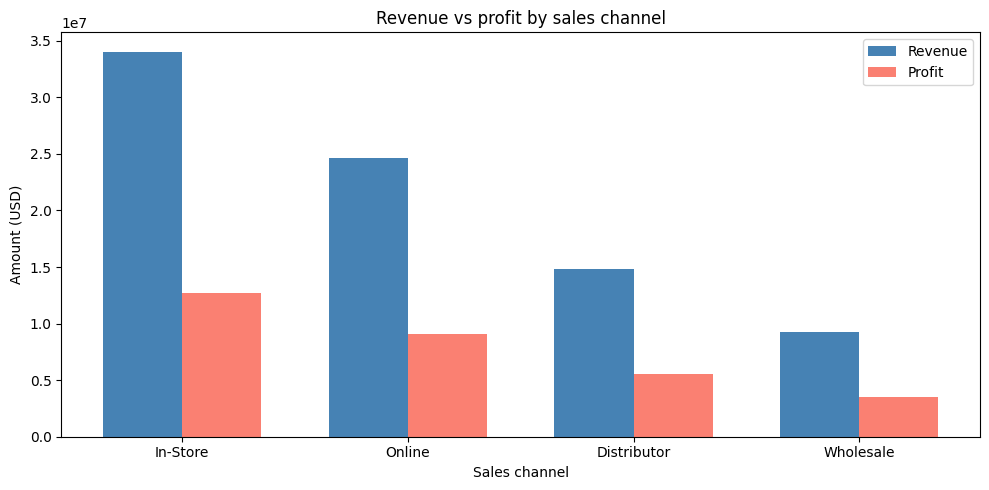

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_channels['Sales Channel']))
width = 0.35

bars1 = ax.bar(x - width/2, df_channels['Ingreso_total'], width, label='Revenue', color='steelblue')
bars2 = ax.bar(x + width/2, df_channels['Ganancia'], width, label='Profit', color='Salmon')

ax.set_title('Revenue vs profit by sales channel')
ax.set_xlabel('Sales channel')
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(df_channels['Sales Channel'])
ax.legend()
plt.tight_layout()
plt.show()

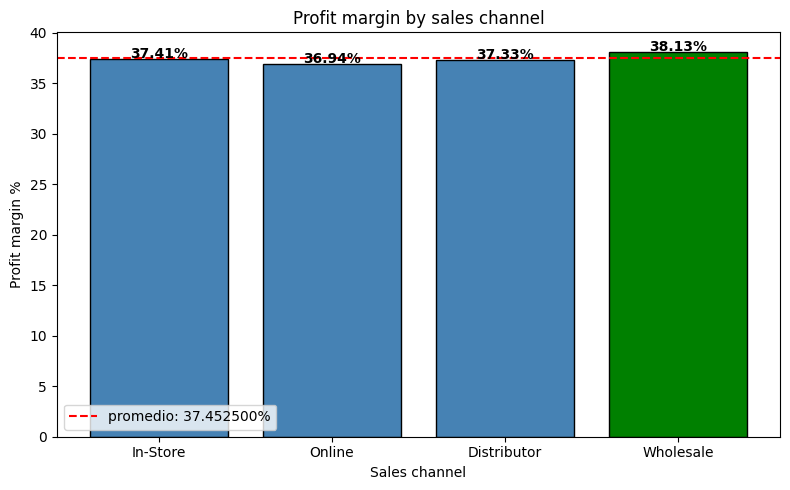

In [5]:
plt.figure(figsize=(8, 5))
colors = ['steelblue' if x < df_channels['Margen_ganancia'].max()
        else 'green' for x in df_channels['Margen_ganancia']]

bars = plt.bar(df_channels['Sales Channel'], df_channels['Margen_ganancia'],
               color=colors, edgecolor='black')

plt.axhline(y=df_channels['Margen_ganancia'].mean(),
            color='red', linestyle='--', label=f'promedio: {df_channels["Margen_ganancia"].mean():2f}%')

for bar, val in zip(bars, df_channels['Margen_ganancia']):
  plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
           f'{val}%', ha='center', fontweight='bold')

plt.title('Profit margin by sales channel')
plt.xlabel('Sales channel')
plt.ylabel('Profit margin %')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
df_warehouses = pd.read_csv('US regional sales warehouse code.csv')
print(df_warehouses.shape)
print(df_warehouses.head())

(6, 7)
  WarehouseCode  Total_ordenes  Total_unidades  Ingreso_total  Costo_total  \
0  WARE-NMK1003           2505           11351     26107132.9  16354295.51   
1  WARE-PUJ1005           1451            6572     14826215.6   9219737.48   
2  WARE-UHY1004           1265            5765     13535742.0   8548736.20   
3  WARE-XYS1001           1222            5557     12574546.6   7921060.49   
4  WARE-MKL1006            857            3816      8737336.0   5466065.80   

     Ganancia  Margen_ganancia  
0  9752837.39            37.36  
1  5606478.12            37.81  
2  4987005.80            36.84  
3  4653486.11            37.01  
4  3271270.20            37.44  


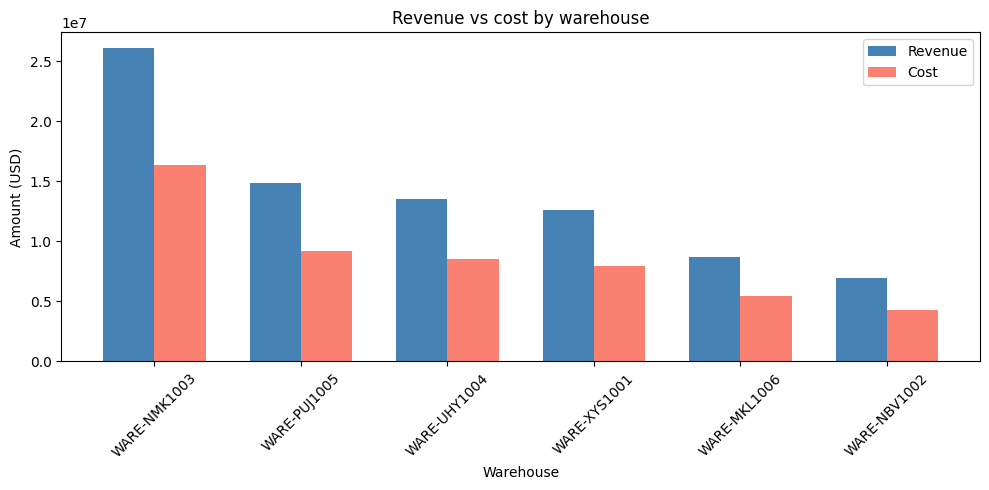

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_warehouses['WarehouseCode']))
width = 0.35

bars1 = ax.bar(x - width/2, df_warehouses['Ingreso_total'], width, label='Revenue', color='steelblue')
bars2 = ax.bar(x + width/2, df_warehouses['Costo_total'], width, label='Cost', color='Salmon')

ax.set_title('Revenue vs cost by warehouse')
ax.set_xlabel('Warehouse')
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(df_warehouses['WarehouseCode'], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

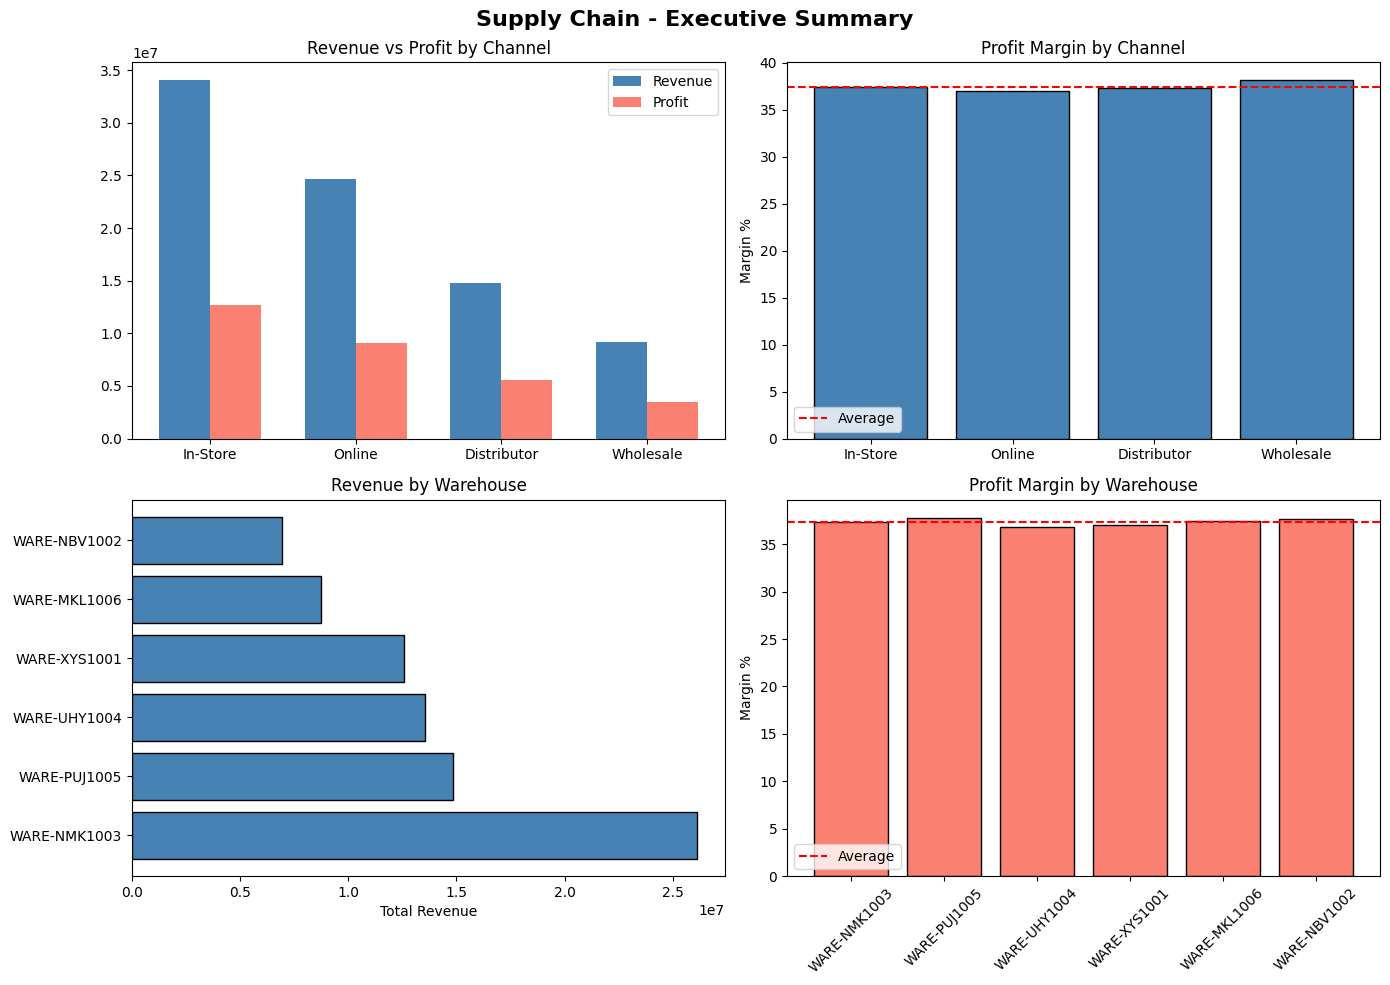

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1 — Revenue vs Profit por canal
x = np.arange(len(df_channels['Sales Channel']))
width = 0.35
axes[0,0].bar(x - width/2, df_channels['Ingreso_total'], width, label='Revenue', color='steelblue')
axes[0,0].bar(x + width/2, df_channels['Ganancia'], width, label='Profit', color='salmon')
axes[0,0].set_title('Revenue vs Profit by Channel')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(df_channels['Sales Channel'])
axes[0,0].legend()

# Gráfica 2 — Margen por canal
axes[0,1].bar(df_channels['Sales Channel'], df_channels['Margen_ganancia'],
              color='steelblue', edgecolor='black')
axes[0,1].axhline(y=df_channels['Margen_ganancia'].mean(),
                  color='red', linestyle='--', label='Average')
axes[0,1].set_title('Profit Margin by Channel')
axes[0,1].set_ylabel('Margin %')
axes[0,1].legend()

# Gráfica 3 — Ingreso por bodega
axes[1,0].barh(df_warehouses['WarehouseCode'], df_warehouses['Ingreso_total'],
               color='steelblue', edgecolor='black')
axes[1,0].set_title('Revenue by Warehouse')
axes[1,0].set_xlabel('Total Revenue')

# Gráfica 4 — Margen por bodega
axes[1,1].bar(df_warehouses['WarehouseCode'], df_warehouses['Margen_ganancia'],
              color='salmon', edgecolor='black')
axes[1,1].axhline(y=df_warehouses['Margen_ganancia'].mean(),
                  color='red', linestyle='--', label='Average')
axes[1,1].set_title('Profit Margin by Warehouse')
axes[1,1].set_ylabel('Margin %')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

plt.suptitle('Supply Chain - Executive Summary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Supply Chain Summary.png', dpi=150, bbox_inches='tight')
plt.show()